In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import seppy
from seppy.loader.soho import soho_load
import cdflib.xarray
import os
import time
import xarray as xr

directory_path = 'C:/Users/clwhit13/sunpy/data/'
averaging = '60min' 
timing_results = {'Format': [], 'Read Time (s)': [], 'Ave Time (s)': [], 'Plot Time (s)': []}

# this is the location that the zarr data will be stored. Once it is created, comment out the cell that writes out the data
fname_zarr = 'C:/Users/clwhit13/sunpy/zarr_soho'

# Use SEPPY to download and read 1 year of SOHO 15 sec data

When you run the code below, you just have to put the dataset name and start/end dates. It then goes and downloads the data from the archive as CDF files and saves them locally on your computer either in a place you pre-specify or defaults to ''C:/Users/USERNAME/sunpy/data/'

- Download CDF files via SunPy/Fido from CDAWeb for CELIAS, EPHIN, ERNE onboard SOHOIt doesn't get it from cloud as far as I can tell, it just seems to use pooch to download the data
- When it fails, it tells you, but you end up having to just run the code below several times until it gets all the files. If you didn't know this, and it does't really tell you, it would be easy to think you have all the data but not actually have all the data
- The read routine puts it into a pandas dataframe which lacks substantail metadata information

Returns df, meta which have the pandas dataframe (df) and metadata (meta) as two separate variables.

# Xarray

In the code below I show an example reading the data using Xarray instead of pandas. Xarray is preferred by many communities because it saves the metadata in a dataset, uses more advanced lazy loading via Dask and allows for coordinate based access which reduces errors in analysis.

# NEEDS

- Contribute CDF engine to Xarray? 
https://docs.xarray.dev/en/stable/getting-started-guide/faq.html#how-do-i-open-format-x-file-as-an-xarray-dataset


In [2]:
start_time = time.time() # Start the timer
df, meta = soho_load(dataset="SOHO_CELIAS-SEM_15S",
                     startdate="2023/06/21",
                     enddate="2024/06/21")
end_time = time.time() #end timer
elapsed_time = end_time - start_time
print(f"Elapsed time: {elapsed_time} seconds")
timing_results['Format'].append('DataFrame')
timing_results['Read Time (s)'].append(elapsed_time)

Elapsed time: 109.15428471565247 seconds


In [3]:
start_time = time.time() # Start the timer
df_ave = df.resample(averaging).mean()
end_time = time.time() #end timer
elapsed_time = end_time - start_time
print(f"Elapsed time: {elapsed_time} seconds")
timing_results['Ave Time (s)'].append(elapsed_time)

Elapsed time: 0.10140085220336914 seconds


Elapsed time: 4.53593635559082 seconds


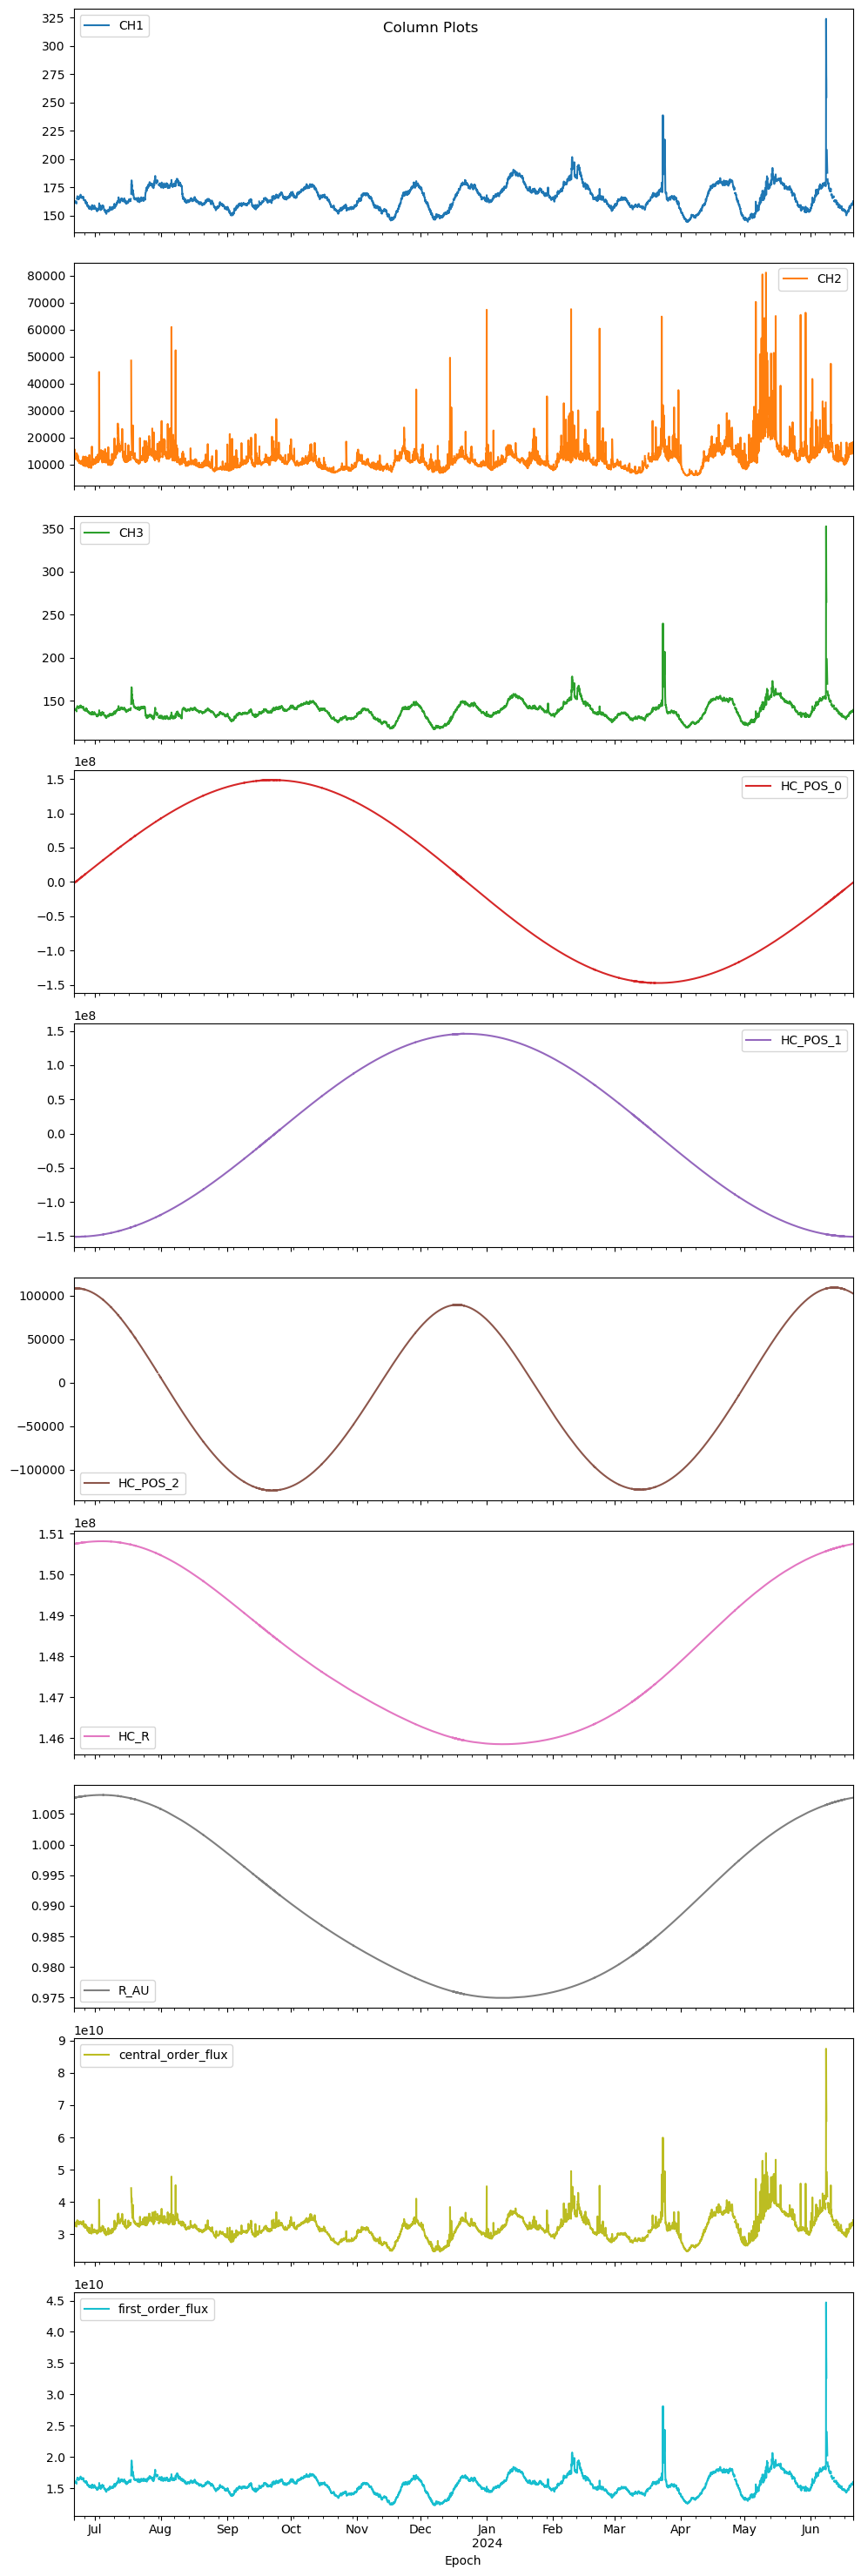

In [4]:
start_time = time.time() # Start the timer
df_ave.plot(subplots=True, layout=(len(df.columns), 1), figsize=(10, len(df.columns) * 3), title="Column Plots")
plt.tight_layout()  # Adjust layout to avoid overlap
end_time = time.time() #end timer
elapsed_time = end_time - start_time
print(f"Elapsed time: {elapsed_time} seconds")
timing_results['Plot Time (s)'].append(elapsed_time)

## List all the files that were downloaded to local computer

In [5]:
with os.scandir(directory_path) as entries:
    files = [directory_path+entry.name for entry in entries if entry.is_file()]
print(len(files),files[0])

366 C:/Users/clwhit13/sunpy/data/soho_celias-sem_15s_20230621_v04.cdf


# Xarray 

Time opening all the data as xarray datasets

In [6]:
start_time = time.time() # Start the timer
datasets = [cdflib.xarray.cdf_to_xarray(fname, fillval_to_nan=True) for fname in files]
ds = xr.concat(datasets, dim='Epoch')
ds = ds.rename({'Epoch':'time'})
end_time = time.time() #end timer
elapsed_time = end_time - start_time
print(f"Elapsed time: {elapsed_time} seconds")
timing_results['Format'].append('Xarray DataSet')
timing_results['Read Time (s)'].append(elapsed_time)
ds

Elapsed time: 68.9326503276825 seconds


<xarray.Dataset> Size: 117MB
Dimensions:             (time: 1950681, dim0: 3)
Coordinates:
  * time                (time) datetime64[ns] 16MB 2023-06-21T00:00:05.011000...
Dimensions without coordinates: dim0
Data variables:
    CH1                 (time) float32 8MB 160.0 160.0 160.0 ... 162.1 162.1
    CH2                 (time) float32 8MB 1.253e+04 1.256e+04 ... 1.529e+04
    CH3                 (time) float32 8MB 137.6 138.1 137.6 ... 138.7 138.7
    first_order_flux    (time) float32 8MB 1.567e+10 1.571e+10 ... 1.593e+10
    central_order_flux  (time) float32 8MB 3.223e+10 3.231e+10 ... 3.343e+10
    HC_POS              (time, dim0) float32 23MB -2.367e+06 ... 1.023e+05
    label_HC_POS        (time, dim0) <U1 23MB 'X' 'Y' 'Z' 'X' ... 'X' 'Y' 'Z'
    HC_R                (time) float32 8MB 1.507e+08 1.507e+08 ... 1.507e+08
    R_AU                (time) float32 8MB 1.008 1.008 1.008 ... 1.008 1.008
Attributes: (12/22)
    Project:                     ['ISTP>International Solar-Terrestrial Physi...
    Source_name:                 ['SOHO>Solar Heliospheric Observatory']
    Discipline:                  ['Solar Physics>Ultraviolet Observations']
    Data_type:                   ['15S>15 second resolution']
    Descriptor:                  ['CELIAS-SEM>Solar Extreme-Ultra-Violet Moni...
    Data_version:                ['4']
    ...                          ...
    Instrument_type:             ['Plasma and Solar Wind']
    LINK_TEXT:                   ['SOHO CELIAS-SEM 15 second data available at']
    LINK_TITLE:                  ['the SOHO Archive']
    HTTP_LINK:                   ['https://soho.nascom.nasa.gov/data/archive....
    Parents:                     ['23_06_21_v4.00']
    Generated_by:                ['Andriy Koval at SPDF from original ASCII f...

# Xarray test resample and plotting

In [8]:
start_time = time.time() # Start the timer
ds_resampled = ds.resample(time=averaging).mean()
end_time = time.time() #end timer
elapsed_time = end_time - start_time
print(f"Elapsed time: {elapsed_time} seconds")
timing_results['Ave Time (s)'].append(elapsed_time)
ds_resampled

Elapsed time: 25.773295879364014 seconds


<xarray.Dataset> Size: 422kB
Dimensions:             (time: 8784, dim0: 3)
Coordinates:
  * time                (time) datetime64[ns] 70kB 2023-06-21 ... 2024-06-20T...
Dimensions without coordinates: dim0
Data variables:
    CH1                 (time) float32 35kB 159.8 160.2 nan ... 161.5 162.7
    CH2                 (time) float32 35kB 1.268e+04 1.273e+04 ... 1.827e+04
    CH3                 (time) float32 35kB 138.0 138.2 nan ... 139.0 139.3
    first_order_flux    (time) float32 35kB 1.569e+10 1.574e+10 ... 1.602e+10
    central_order_flux  (time) float32 35kB 3.23e+10 3.24e+10 ... 3.439e+10
    HC_POS              (time, dim0) float32 105kB -2.315e+06 ... 1.023e+05
    HC_R                (time) float32 35kB 1.507e+08 1.507e+08 ... 1.507e+08
    R_AU                (time) float32 35kB 1.008 1.008 nan ... 1.008 1.008
Attributes: (12/22)
    Project:                     ['ISTP>International Solar-Terrestrial Physi...
    Source_name:                 ['SOHO>Solar Heliospheric Observatory']
    Discipline:                  ['Solar Physics>Ultraviolet Observations']
    Data_type:                   ['15S>15 second resolution']
    Descriptor:                  ['CELIAS-SEM>Solar Extreme-Ultra-Violet Moni...
    Data_version:                ['4']
    ...                          ...
    Instrument_type:             ['Plasma and Solar Wind']
    LINK_TEXT:                   ['SOHO CELIAS-SEM 15 second data available at']
    LINK_TITLE:                  ['the SOHO Archive']
    HTTP_LINK:                   ['https://soho.nascom.nasa.gov/data/archive....
    Parents:                     ['23_06_21_v4.00']
    Generated_by:                ['Andriy Koval at SPDF from original ASCII f...

Elapsed time: 1.2073676586151123 seconds


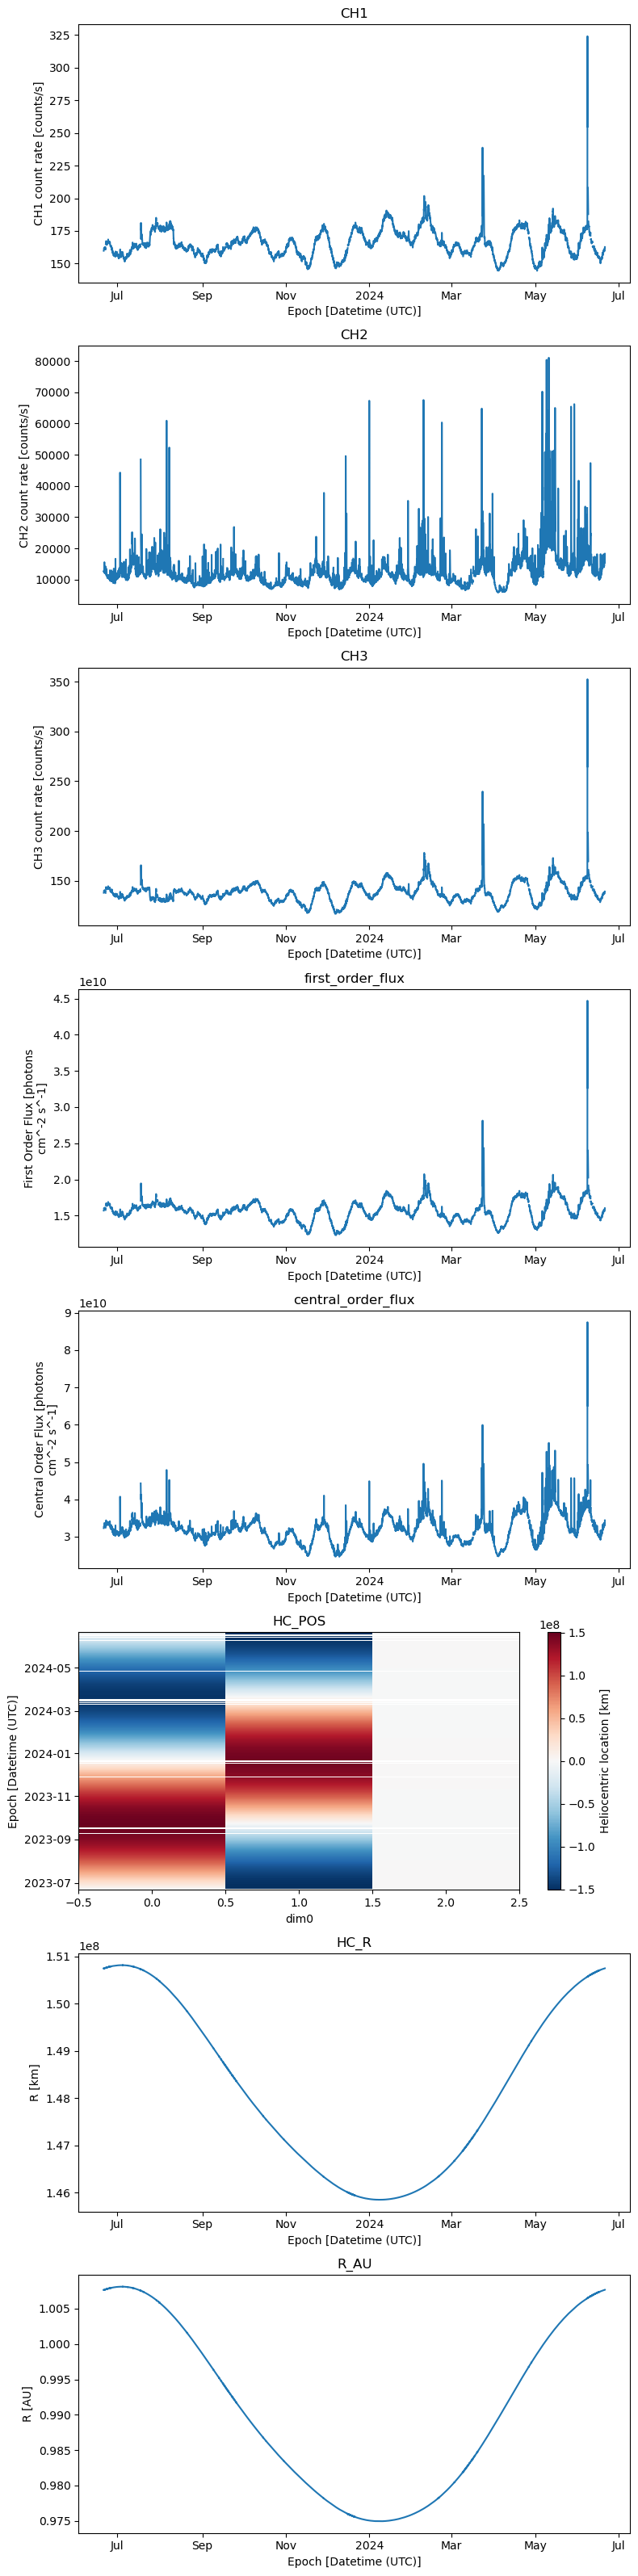

In [9]:
start_time = time.time() # Start the timer
num_vars = len(ds_resampled.data_vars)
fig, axes = plt.subplots(num_vars, 1, figsize=(8, num_vars * 4), squeeze=False)
for i, (var_name, var_data) in enumerate(ds_resampled.data_vars.items()):
    var_data.plot(ax=axes[i, 0])  # Plot on the correct subplot axis
    axes[i, 0].set_title(var_name)  # Title for each subplot
# Adjust layout
plt.tight_layout()
end_time = time.time() #end timer
elapsed_time = end_time - start_time
print(f"Elapsed time: {elapsed_time} seconds")
timing_results['Plot Time (s)'].append(elapsed_time)

In [10]:
results_df = pd.DataFrame(timing_results)
print(results_df)

           Format  Read Time (s)  Ave Time (s)  Plot Time (s)
0       DataFrame     109.154285      0.101401       4.535936
1  Xarray DataSet      68.932650     25.773296       1.207368
